In [1]:
from pathlib import Path
import sys

CFR_DIR = Path.cwd() if Path.cwd().name == 'cfr' else Path.cwd() / 'cfr'
PROJECT_ROOT = CFR_DIR.parent
for path in [str(PROJECT_ROOT), str(CFR_DIR)]:
    if path not in sys.path:
        sys.path.insert(0, path)

from games.kuhn import KuhnPoker
from agents.counterfactualregret import CounterFactualRegret

In [2]:
g = KuhnPoker()

In [3]:
agent_classes = [ CounterFactualRegret, CounterFactualRegret ]
my_agents = {}
for i, agent in enumerate(g.agents):
    my_agents[agent] = agent_classes[i](game=g, agent=agent)

In [4]:
g.reset()
while not g.done():
    g.render()
    print(f"Agent {g.agent_selection}")
    action = my_agents[g.agent_selection].action()
    print(f"Action {action} - move {g.action_move(action)}")
    g.step(action)
g.render()
for agent in g.agents:
    print(f"Reward {agent} = {g.reward(agent)}")

agent_0 K 
agent_1 J 
Agent agent_0
Action 0 - move p
agent_0 K p
agent_1 J p
Agent agent_1
Action 1 - move b
agent_0 K pb
agent_1 J pb
Agent agent_0
Action 1 - move b
agent_0 K pbb
agent_1 J pbb
Reward agent_0 = 2
Reward agent_1 = -2


In [5]:
for agent in g.agents:
    print('Training agent ' + agent)
    my_agents[agent].train(1000)
    print(dict(map(lambda n: (n, my_agents[agent].node_dict[n].policy()), my_agents[agent].node_dict.keys())))

Training agent agent_0
{'2': array([0.00334448, 0.99665552]), '0p': array([0.99250268, 0.00749732]), '2pb': array([0.44444444, 0.55555556]), '0b': array([0.99638445, 0.00361555]), '0': array([0.99725275, 0.00274725]), '2p': array([0.00335383, 0.99664617]), '0pb': array([0.99718706, 0.00281294]), '2b': array([0.00595829, 0.99404171]), '1': array([0.82889823, 0.17110177]), '1pb': array([0.00311473, 0.99688527]), '1p': array([0.97821577, 0.02178423]), '1b': array([0.02037767, 0.97962233])}
Training agent agent_1
{'2': array([0.09616901, 0.90383099]), '1p': array([0.9915015, 0.0084985]), '2pb': array([0.03737576, 0.96262424]), '1b': array([0.00976805, 0.99023195]), '0p': array([0.94438058, 0.05561942]), '0b': array([0.99593459, 0.00406541]), '0': array([0.97298633, 0.02701367]), '0pb': array([0.99703741, 0.00296259]), '2p': array([0.00205198, 0.99794802]), '2b': array([0.00395778, 0.99604222]), '1': array([0.99392097, 0.00607903]), '1pb': array([0.04257278, 0.95742722])}


In [6]:
cum_rewards = dict(map(lambda agent: (agent, 0.), g.agents))
niter = 2000
for _ in range(niter):
    g.reset()
    turn = 0
    while not g.done():
        #print('Turn: ', turn)
        #print('\tPlayer: ', g.agent_selection)
        #print('\tObservation: ', g.observe(g.agent_selection))
        a = my_agents[g.agent_selection].action()
        #print('\tAction: ', g._moves[a])
        g.step(action=a)
        turn += 1
    #print('Rewards: ', g.rewards)
    for agent in g.agents:
        cum_rewards[agent] += g.rewards[agent]
print('Average rewards:', dict(map(lambda agent: (agent, cum_rewards[agent]/niter), g.agents)))


Average rewards: {'agent_0': -0.003, 'agent_1': 0.003}


## Experimentos de valor con CFR

Entrenamos agentes CFR con distintas cantidades de iteraciones y evaluamos el valor promedio obtenido por cada agente en partidas simuladas. Para Kuhn Poker con jugador inicial fijo, esto permite observar cómo cambia el valor esperado de `agent_0` y `agent_1` a medida que la política promedio aprendida se estabiliza.

En Kuhn Poker de 2 jugadores sí hay una referencia teórica conocida: el equilibrio de Nash tiene valor esperado `-1/18` para el jugador inicial y `+1/18` para el segundo jugador. En la notebook lo verificamos de dos maneras: las gráficas de valor/error comparan contra esa línea teórica, y la celda de `Política aprendida por agent_*` muestra la estrategia promedio aprendida por CFR para cada infoset (`carta + historial`).

In [7]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter

CFR_DIR = Path.cwd() if Path.cwd().name == 'cfr' else Path.cwd() / 'cfr'
PROJECT_ROOT = CFR_DIR.parent
for path in [str(PROJECT_ROOT), str(CFR_DIR)]:
    if path not in sys.path:
        sys.path.insert(0, path)

from games.kuhn import KuhnPoker
from agents.counterfactualregret import CounterFactualRegret


def train_cfr_agents(niter, initial_player=0, seed=None):
    game = KuhnPoker(initial_player=initial_player, seed=seed, render_mode='')
    agents = {agent: CounterFactualRegret(game=game, agent=agent) for agent in game.agents}
    start = perf_counter()
    for agent in game.agents:
        agents[agent].train(niter)
    return game, agents, perf_counter() - start


def bind_agents_to_game(agents, game):
    for agent in game.agents:
        agents[agent].game = game


def play_game(game, agents):
    bind_agents_to_game(agents, game)
    game.reset()
    while not game.done():
        action = agents[game.agent_selection].action()
        game.step(action)
    return game.rewards.copy()


def evaluate_agents(agents, n_games=2000, initial_player=0, seed=None):
    game = KuhnPoker(initial_player=initial_player, seed=seed, render_mode='')
    cum_rewards = {agent: 0.0 for agent in game.agents}
    for _ in range(n_games):
        rewards = play_game(game, agents)
        for agent, reward in rewards.items():
            cum_rewards[agent] += reward
    return {agent: cum_rewards[agent] / n_games for agent in game.agents}


def show_policies(agent, title, max_rows=12):
    print(title)
    for obs in sorted(agent.node_dict.keys())[:max_rows]:
        policy = agent.node_dict[obs].policy()
        print(f"  {obs}: pass={policy[0]:.3f}, bet={policy[1]:.3f}")

niter=   10 | value agent_0=-0.0500 | value agent_1=0.0500 | train_time=0.039s
niter=  100 | value agent_0=-0.0417 | value agent_1=0.0417 | train_time=0.337s
niter=  500 | value agent_0=-0.0610 | value agent_1=0.0610 | train_time=1.824s
niter= 1000 | value agent_0=-0.0683 | value agent_1=0.0683 | train_time=3.753s
niter= 5000 | value agent_0=-0.1107 | value agent_1=0.1107 | train_time=18.381s


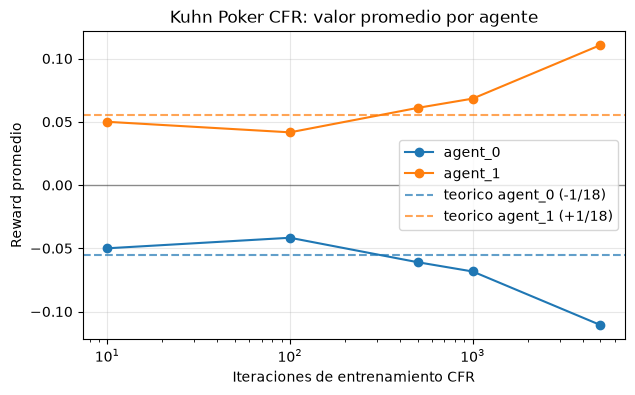

In [8]:
training_iters = [10, 100, 500, 1000, 5000]
eval_games = 3000
initial_player = 0

results = []
last_agents = None

for niter in training_iters:
    game, agents, train_time = train_cfr_agents(
        niter=niter,
        initial_player=initial_player,
        seed=None,
    )
    values = evaluate_agents(
        agents=agents,
        n_games=eval_games,
        initial_player=initial_player,
        seed=None,
    )
    results.append({
        'niter': niter,
        'train_time': train_time,
        **values,
    })
    last_agents = agents
    print(
        f"niter={niter:>5} | "
        f"value agent_0={values['agent_0']:.4f} | "
        f"value agent_1={values['agent_1']:.4f} | "
        f"train_time={train_time:.3f}s"
    )

kuhn_value = 1 / 18

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot([r['niter'] for r in results], [r['agent_0'] for r in results], marker='o', label='agent_0')
ax.plot([r['niter'] for r in results], [r['agent_1'] for r in results], marker='o', label='agent_1')
ax.axhline(0, color='black', linewidth=1, alpha=0.4)
ax.axhline(-kuhn_value, color='tab:blue', linestyle='--', alpha=0.7, label='teorico agent_0 (-1/18)')
ax.axhline(kuhn_value, color='tab:orange', linestyle='--', alpha=0.7, label='teorico agent_1 (+1/18)')
ax.set_xscale('log')
ax.set_title('Kuhn Poker CFR: valor promedio por agente')
ax.set_xlabel('Iteraciones de entrenamiento CFR')
ax.set_ylabel('Reward promedio')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [9]:
for agent in sorted(last_agents.keys()):
    show_policies(last_agents[agent], title=f"Política aprendida por {agent}")

Política aprendida por agent_0
  0: pass=0.697, bet=0.303
  0b: pass=0.999, bet=0.001
  0p: pass=0.643, bet=0.357
  0pb: pass=0.999, bet=0.001
  1: pass=0.992, bet=0.008
  1b: pass=0.567, bet=0.433
  1p: pass=0.998, bet=0.002
  1pb: pass=0.423, bet=0.577
  2: pass=0.126, bet=0.874
  2b: pass=0.001, bet=0.999
  2p: pass=0.001, bet=0.999
  2pb: pass=0.003, bet=0.997
Política aprendida por agent_1
  0: pass=0.678, bet=0.322
  0b: pass=0.999, bet=0.001
  0p: pass=0.675, bet=0.325
  0pb: pass=0.999, bet=0.001
  1: pass=0.986, bet=0.014
  1b: pass=0.574, bet=0.426
  1p: pass=0.996, bet=0.004
  1pb: pass=0.363, bet=0.637
  2: pass=0.050, bet=0.950
  2b: pass=0.002, bet=0.998
  2p: pass=0.005, bet=0.995
  2pb: pass=0.009, bet=0.991


## Experimento largo: convergencia hacia el valor analítico

Kuhn Poker tiene valor teórico `-1/18` para el jugador inicial y `+1/18` para el segundo jugador. La celda siguiente repite el experimento con más iteraciones CFR y más partidas de evaluación para reducir el ruido de la estimación empírica. Puede demorar bastante más que el experimento anterior.

niter=  1000 | value agent_0=-0.05025 | value agent_1=0.05025 | err agent_0=0.00531 | err agent_1=0.00531 | train_time=3.74s
niter=  5000 | value agent_0=-0.04945 | value agent_1=0.04945 | err agent_0=0.00611 | err agent_1=0.00611 | train_time=18.15s
niter= 10000 | value agent_0=-0.05185 | value agent_1=0.05185 | err agent_0=0.00371 | err agent_1=0.00371 | train_time=34.72s
niter= 25000 | value agent_0=-0.05560 | value agent_1=0.05560 | err agent_0=0.00004 | err agent_1=0.00004 | train_time=83.10s
niter= 50000 | value agent_0=-0.05900 | value agent_1=0.05900 | err agent_0=0.00344 | err agent_1=0.00344 | train_time=364.29s


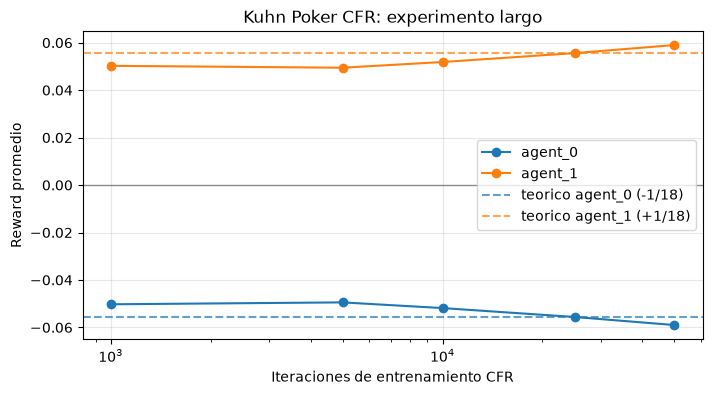

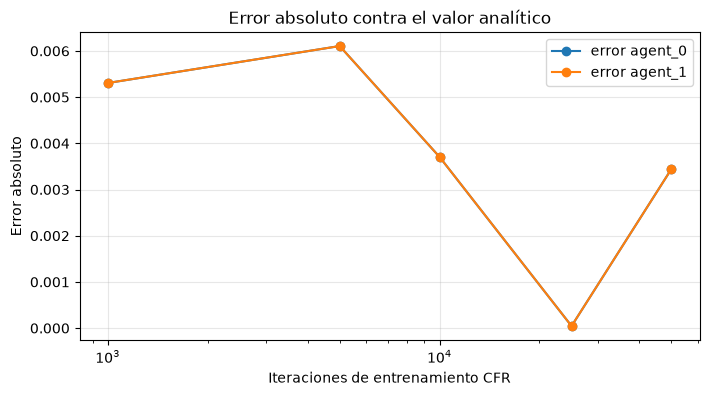

In [10]:
long_training_iters = [1_000, 5_000, 10_000, 25_000, 50_000]
long_eval_games = 20_000
initial_player = 0
kuhn_value = 1 / 18

long_results = []
long_last_agents = None

for niter in long_training_iters:
    game, agents, train_time = train_cfr_agents(
        niter=niter,
        initial_player=initial_player,
        seed=None,
    )
    values = evaluate_agents(
        agents=agents,
        n_games=long_eval_games,
        initial_player=initial_player,
        seed=None,
    )
    error_agent_0 = abs(values['agent_0'] - (-kuhn_value))
    error_agent_1 = abs(values['agent_1'] - kuhn_value)
    long_results.append({
        'niter': niter,
        'train_time': train_time,
        'error_agent_0': error_agent_0,
        'error_agent_1': error_agent_1,
        **values,
    })
    long_last_agents = agents
    print(
        f"niter={niter:>6} | "
        f"value agent_0={values['agent_0']:.5f} | "
        f"value agent_1={values['agent_1']:.5f} | "
        f"err agent_0={error_agent_0:.5f} | "
        f"err agent_1={error_agent_1:.5f} | "
        f"train_time={train_time:.2f}s"
    )

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([r['niter'] for r in long_results], [r['agent_0'] for r in long_results], marker='o', label='agent_0')
ax.plot([r['niter'] for r in long_results], [r['agent_1'] for r in long_results], marker='o', label='agent_1')
ax.axhline(0, color='black', linewidth=1, alpha=0.4)
ax.axhline(-kuhn_value, color='tab:blue', linestyle='--', alpha=0.7, label='teorico agent_0 (-1/18)')
ax.axhline(kuhn_value, color='tab:orange', linestyle='--', alpha=0.7, label='teorico agent_1 (+1/18)')
ax.set_xscale('log')
ax.set_title('Kuhn Poker CFR: experimento largo')
ax.set_xlabel('Iteraciones de entrenamiento CFR')
ax.set_ylabel('Reward promedio')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([r['niter'] for r in long_results], [r['error_agent_0'] for r in long_results], marker='o', label='error agent_0')
ax.plot([r['niter'] for r in long_results], [r['error_agent_1'] for r in long_results], marker='o', label='error agent_1')
ax.set_xscale('log')
ax.set_title('Error absoluto contra el valor analítico')
ax.set_xlabel('Iteraciones de entrenamiento CFR')
ax.set_ylabel('Error absoluto')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

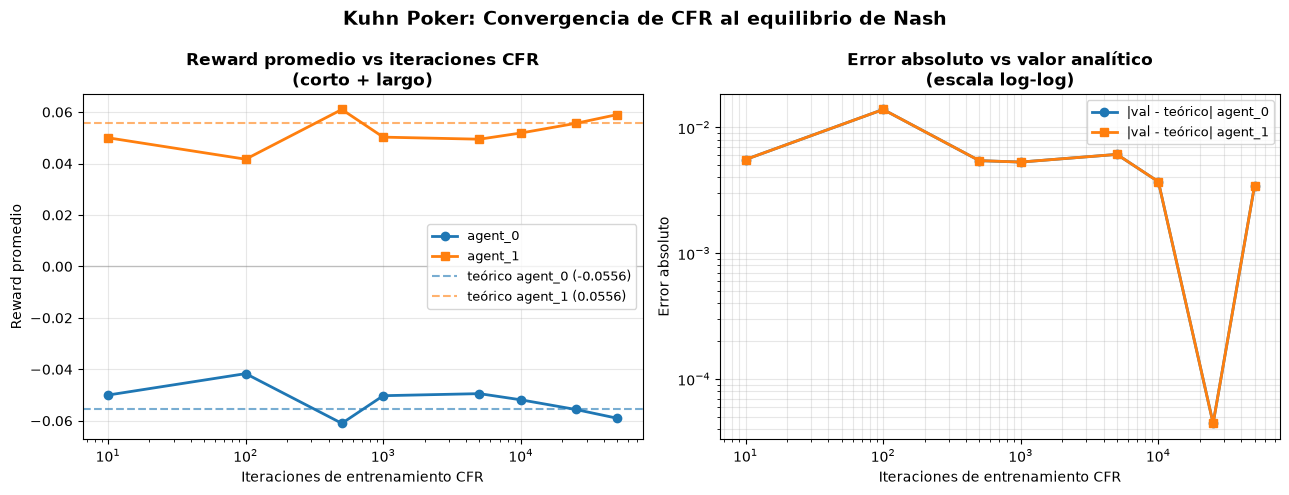


Valor teórico: agent_0 = -0.055556, agent_1 = 0.055556
Con 50,000 iteraciones: agent_0 = -0.059000, agent_1 = 0.059000
Error agent_0 = 0.003444  |  Error agent_1 = 0.003444


In [11]:
# Convergencia combinada: short + long experiments
import matplotlib.pyplot as plt

kuhn_value = 1 / 18

# Merge ambos experimentos (deduplica por niter, long_results tiene prioridad)
short_by_niter = {r['niter']: r for r in results}
long_by_niter  = {r['niter']: r for r in long_results}
merged = {**short_by_niter, **long_by_niter}
merged_sorted = sorted(merged.values(), key=lambda r: r['niter'])

niters   = [r['niter']    for r in merged_sorted]
vals_0   = [r['agent_0']  for r in merged_sorted]
vals_1   = [r['agent_1']  for r in merged_sorted]
errs_0   = [abs(r['agent_0'] - (-kuhn_value)) for r in merged_sorted]
errs_1   = [abs(r['agent_1'] - kuhn_value)    for r in merged_sorted]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: reward promedio vs iteraciones
ax1.plot(niters, vals_0, marker='o', linewidth=2, label='agent_0', color='tab:blue')
ax1.plot(niters, vals_1, marker='s', linewidth=2, label='agent_1', color='tab:orange')
ax1.axhline(-kuhn_value, color='tab:blue',   linestyle='--', alpha=0.6, label=f'teórico agent_0 ({-kuhn_value:.4f})')
ax1.axhline( kuhn_value, color='tab:orange', linestyle='--', alpha=0.6, label=f'teórico agent_1 ({kuhn_value:.4f})')
ax1.axhline(0, color='gray', linewidth=1, alpha=0.4)
ax1.set_xscale('log')
ax1.set_title('Reward promedio vs iteraciones CFR\n(corto + largo)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Iteraciones de entrenamiento CFR', fontsize=10)
ax1.set_ylabel('Reward promedio', fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel derecho: error absoluto vs valor teórico
ax2.plot(niters, errs_0, marker='o', linewidth=2, label='|val - teórico| agent_0', color='tab:blue')
ax2.plot(niters, errs_1, marker='s', linewidth=2, label='|val - teórico| agent_1', color='tab:orange')
ax2.axhline(0, color='gray', linewidth=1, alpha=0.4)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_title('Error absoluto vs valor analítico\n(escala log-log)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Iteraciones de entrenamiento CFR', fontsize=10)
ax2.set_ylabel('Error absoluto', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, which='both', alpha=0.3)

fig.suptitle('Kuhn Poker: Convergencia de CFR al equilibrio de Nash', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nValor teórico: agent_0 = {-kuhn_value:.6f}, agent_1 = {+kuhn_value:.6f}")
final = merged_sorted[-1]
print(f"Con {final['niter']:,} iteraciones: agent_0 = {final['agent_0']:.6f}, agent_1 = {final['agent_1']:.6f}")
print(f"Error agent_0 = {abs(final['agent_0'] - (-kuhn_value)):.6f}  |  Error agent_1 = {abs(final['agent_1'] - kuhn_value):.6f}")

## Comparación entre agentes

Hasta ahora la notebook evalúa principalmente `CFR` contra `CFR`. En esta sección comparamos pares de agentes: `CFR`, `MCTS` y `Random`.

Nota importante: `CFR` es el agente más apropiado para Kuhn Poker porque el juego es de información imperfecta. `MCTS`, tal como está implementado en este proyecto, usa clones del estado completo durante la búsqueda; por eso funciona como baseline experimental, pero no representa un algoritmo correcto de información imperfecta para Poker.

In [12]:
import importlib.util


def load_class(module_path, class_name):
    spec = importlib.util.spec_from_file_location(class_name, module_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return getattr(module, class_name)


MonteCarloTreeSearch = load_class(PROJECT_ROOT / 'agents' / 'mcts_t.py', 'MonteCarloTreeSearch')
RandomAgent = load_class(PROJECT_ROOT / 'agents' / 'agent_random.py', 'RandomAgent')


def build_agent(kind, game, agent, cfr_niter=5_000, mcts_simulations=100, mcts_rollouts=10):
    if kind == 'cfr':
        player = CounterFactualRegret(game=game, agent=agent)
        player.train(cfr_niter)
        return player
    if kind == 'mcts':
        return MonteCarloTreeSearch(
            game=game,
            agent=agent,
            simulations=mcts_simulations,
            rollouts=mcts_rollouts,
        )
    if kind == 'random':
        return RandomAgent(game=game, agent=agent)
    raise ValueError(f'Unknown agent kind: {kind}')


def evaluate_agent_pair(
    kind_agent_0,
    kind_agent_1,
    n_games=2_000,
    initial_player=0,
    cfr_niter=5_000,
    mcts_simulations=100,
    mcts_rollouts=10,
    seed=None,
):
    train_game = KuhnPoker(initial_player=initial_player, seed=seed, render_mode='')
    start = perf_counter()
    agents = {
        'agent_0': build_agent(kind_agent_0, train_game, 'agent_0', cfr_niter, mcts_simulations, mcts_rollouts),
        'agent_1': build_agent(kind_agent_1, train_game, 'agent_1', cfr_niter, mcts_simulations, mcts_rollouts),
    }
    setup_time = perf_counter() - start

    eval_game = KuhnPoker(initial_player=initial_player, seed=seed, render_mode='')
    cum_rewards = {agent: 0.0 for agent in eval_game.agents}
    wins = {agent: 0 for agent in eval_game.agents}
    draws = 0

    start = perf_counter()
    for _ in range(n_games):
        rewards = play_game(eval_game, agents)
        for agent, reward in rewards.items():
            cum_rewards[agent] += reward
        if rewards['agent_0'] > rewards['agent_1']:
            wins['agent_0'] += 1
        elif rewards['agent_1'] > rewards['agent_0']:
            wins['agent_1'] += 1
        else:
            draws += 1
    eval_time = perf_counter() - start

    return {
        'agent_0_kind': kind_agent_0,
        'agent_1_kind': kind_agent_1,
        'agent_0_value': cum_rewards['agent_0'] / n_games,
        'agent_1_value': cum_rewards['agent_1'] / n_games,
        'agent_0_wins': wins['agent_0'],
        'agent_1_wins': wins['agent_1'],
        'draws': draws,
        'setup_time': setup_time,
        'eval_time': eval_time,
    }


agent_matchups = [
    ('cfr', 'cfr'),
    ('cfr', 'mcts'),
    ('mcts', 'cfr'),
    ('mcts', 'mcts'),
    ('cfr', 'random'),
    ('random', 'cfr'),
    ('mcts', 'random'),
    ('random', 'mcts'),
    ('random', 'random'),
]

comparison_results = []
for kind_0, kind_1 in agent_matchups:
    result = evaluate_agent_pair(
        kind_agent_0=kind_0,
        kind_agent_1=kind_1,
        n_games=2_000,
        initial_player=0,
        cfr_niter=5_000,
        mcts_simulations=100,
        mcts_rollouts=10,
        seed=None,
    )
    comparison_results.append(result)
    print(
        f"{kind_0:>6} vs {kind_1:<6} | "
        f"value agent_0={result['agent_0_value']:.4f} | "
        f"value agent_1={result['agent_1_value']:.4f} | "
        f"wins=({result['agent_0_wins']}, {result['agent_1_wins']}) | "
        f"setup={result['setup_time']:.2f}s | eval={result['eval_time']:.2f}s"
    )

   cfr vs cfr    | value agent_0=-0.0680 | value agent_1=0.0680 | wins=(1005, 995) | setup=48.87s | eval=0.14s
   cfr vs mcts   | value agent_0=-0.1400 | value agent_1=0.1400 | wins=(985, 1015) | setup=26.83s | eval=498.27s
  mcts vs cfr    | value agent_0=0.0685 | value agent_1=-0.0685 | wins=(975, 1025) | setup=19.29s | eval=573.42s
  mcts vs mcts   | value agent_0=-0.0150 | value agent_1=0.0150 | wins=(985, 1015) | setup=0.00s | eval=1009.88s
   cfr vs random | value agent_0=0.0560 | value agent_1=-0.0560 | wins=(906, 1094) | setup=19.82s | eval=0.16s
random vs cfr    | value agent_0=-0.1330 | value agent_1=0.1330 | wins=(1084, 916) | setup=19.15s | eval=0.15s
  mcts vs random | value agent_0=0.1900 | value agent_1=-0.1900 | wins=(958, 1042) | setup=0.00s | eval=625.69s
random vs mcts   | value agent_0=-0.3605 | value agent_1=0.3605 | wins=(1003, 997) | setup=0.00s | eval=512.01s
random vs random | value agent_0=0.1210 | value agent_1=-0.1210 | wins=(1117, 883) | setup=0.00s | eval=

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_20964\250344445.py:46: UserWarning: Glyph 11044 (\N{BLACK LARGE CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
c:\Users\USUARIO\Documents\ORT\MasterIA\multiagente\Alternating Games\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11044 (\N{BLACK LARGE CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


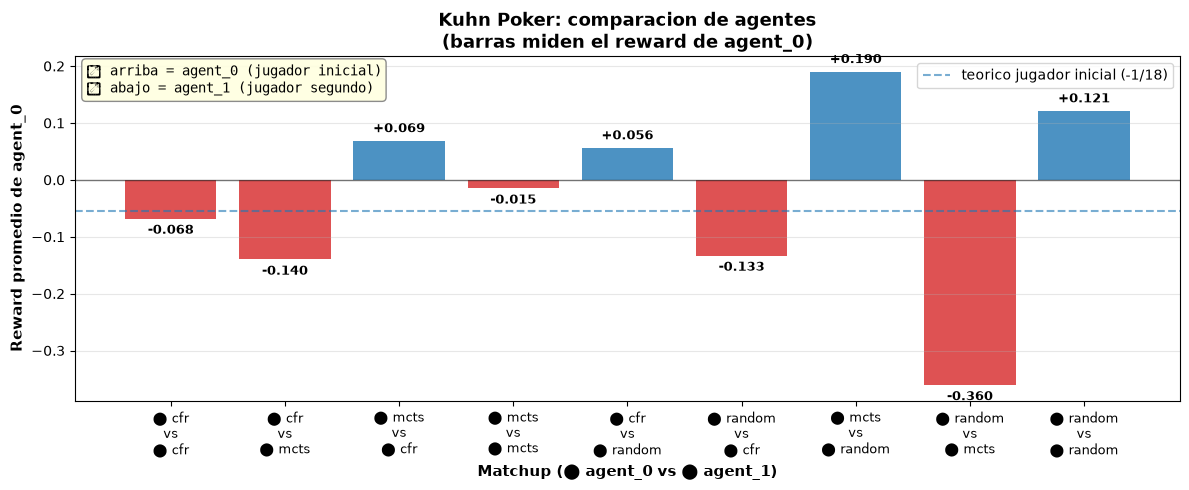


INTERPRETACION
• agent_0 siempre es el PRIMER agente (jugador inicial)
• agent_1 siempre es el SEGUNDO agente
• Valores POSITIVOS (azul): agent_0 gana mas
• Valores NEGATIVOS (rojo): agent_1 gana mas

Mejor resultado para agent_0: mcts (agent_0) vs random (agent_1) → +0.190
Peor resultado para agent_0: random (agent_0) vs mcts (agent_1) → -0.360


In [13]:
labels = [
    f"⬤ {r['agent_0_kind']}\nvs\n⬤ {r['agent_1_kind']}" 
    for r in comparison_results
]
values = [r['agent_0_value'] for r in comparison_results]

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['tab:blue' if value >= 0 else 'tab:red' for value in values]
bars = ax.bar(labels, values, color=colors, alpha=0.8)

# Add numeric values on bars
for bar, value in zip(bars, values):
    offset = 0.01 if value >= 0 else -0.01
    va = 'bottom' if value >= 0 else 'top'
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + offset,
        f'{value:+.3f}',
        ha='center',
        va=va,
        fontsize=9,
        fontweight='bold'
    )

ax.axhline(0, color='black', linewidth=1, alpha=0.5)
ax.axhline(-1 / 18, color='tab:blue', linestyle='--', alpha=0.6, label='teorico jugador inicial (-1/18)')

# Add explanation text box
ax.text(
    0.01,
    0.98,
    '⬤ arriba = agent_0 (jugador inicial)\n⬤ abajo = agent_1 (jugador segundo)',
    transform=ax.transAxes,
    va='top',
    fontsize=10,
    bbox={'boxstyle': 'round', 'facecolor': 'lightyellow', 'alpha': 0.9, 'edgecolor': 'gray'},
    fontfamily='monospace'
)

ax.set_title('Kuhn Poker: comparacion de agentes\n(barras miden el reward de agent_0)', fontsize=13, fontweight='bold')
ax.set_ylabel('Reward promedio de agent_0', fontsize=11, fontweight='bold')
ax.set_xlabel('Matchup (⬤ agent_0 vs ⬤ agent_1)', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', rotation=0, labelsize=9)
ax.grid(True, axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

best = max(comparison_results, key=lambda r: r['agent_0_value'])
worst = min(comparison_results, key=lambda r: r['agent_0_value'])
print(
    '\n' + '='*80 + '\n'
    'INTERPRETACION\n'
    + '='*80 + '\n'
    f"• agent_0 siempre es el PRIMER agente (jugador inicial)\n"
    f"• agent_1 siempre es el SEGUNDO agente\n"
    f"• Valores POSITIVOS (azul): agent_0 gana mas\n"
    f"• Valores NEGATIVOS (rojo): agent_1 gana mas\n\n"
    f"Mejor resultado para agent_0: {best['agent_0_kind']} (agent_0) vs {best['agent_1_kind']} (agent_1) → {best['agent_0_value']:+.3f}\n"
    f"Peor resultado para agent_0: {worst['agent_0_kind']} (agent_0) vs {worst['agent_1_kind']} (agent_1) → {worst['agent_0_value']:+.3f}\n"
    + '='*80
)

## Comparación con ISMCTS

`ISMCTS` (*Information Set Monte Carlo Tree Search*) adapta MCTS a juegos de información imperfecta. En vez de buscar directamente sobre el estado real completo, cada simulación usa una determinización compatible con lo que sabe el agente: en Kuhn Poker mantiene fija su carta y remuestrea la carta privada del rival.

Esto lo vuelve más apropiado que `MCTS` para Poker. Aun así, esta implementación sigue siendo una versión experimental y simple: usa rollouts aleatorios y no aprende una política persistente como `CFR`.

In [14]:
import importlib.util


def load_class(module_path, class_name):
    spec = importlib.util.spec_from_file_location(class_name, module_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return getattr(module, class_name)


InformationSetMCTS = load_class(PROJECT_ROOT / 'agents' / 'ismcts.py', 'InformationSetMCTS')
MonteCarloTreeSearch = load_class(PROJECT_ROOT / 'agents' / 'mcts_t.py', 'MonteCarloTreeSearch')
RandomAgent = load_class(PROJECT_ROOT / 'agents' / 'agent_random.py', 'RandomAgent')


def build_search_agent(
    kind,
    game,
    agent,
    cfr_niter=5_000,
    mcts_simulations=100,
    mcts_rollouts=10,
    ismcts_simulations=200,
    ismcts_rollouts=5,
):
    if kind == 'cfr':
        player = CounterFactualRegret(game=game, agent=agent)
        player.train(cfr_niter)
        return player
    if kind == 'ismcts':
        return InformationSetMCTS(
            game=game,
            agent=agent,
            simulations=ismcts_simulations,
            rollouts=ismcts_rollouts,
        )
    if kind == 'mcts':
        return MonteCarloTreeSearch(
            game=game,
            agent=agent,
            simulations=mcts_simulations,
            rollouts=mcts_rollouts,
        )
    if kind == 'random':
        return RandomAgent(game=game, agent=agent)
    raise ValueError(f'Unknown agent kind: {kind}')


def evaluate_search_pair(
    kind_agent_0,
    kind_agent_1,
    n_games=500,
    initial_player=0,
    cfr_niter=5_000,
    mcts_simulations=100,
    mcts_rollouts=10,
    ismcts_simulations=200,
    ismcts_rollouts=5,
    seed=None,
):
    train_game = KuhnPoker(initial_player=initial_player, seed=seed, render_mode='')
    start = perf_counter()
    agents = {
        'agent_0': build_search_agent(
            kind_agent_0,
            train_game,
            'agent_0',
            cfr_niter,
            mcts_simulations,
            mcts_rollouts,
            ismcts_simulations,
            ismcts_rollouts,
        ),
        'agent_1': build_search_agent(
            kind_agent_1,
            train_game,
            'agent_1',
            cfr_niter,
            mcts_simulations,
            mcts_rollouts,
            ismcts_simulations,
            ismcts_rollouts,
        ),
    }
    setup_time = perf_counter() - start

    eval_game = KuhnPoker(initial_player=initial_player, seed=seed, render_mode='')
    cum_rewards = {agent: 0.0 for agent in eval_game.agents}
    wins = {agent: 0 for agent in eval_game.agents}
    draws = 0

    start = perf_counter()
    for _ in range(n_games):
        rewards = play_game(eval_game, agents)
        for agent, reward in rewards.items():
            cum_rewards[agent] += reward
        if rewards['agent_0'] > rewards['agent_1']:
            wins['agent_0'] += 1
        elif rewards['agent_1'] > rewards['agent_0']:
            wins['agent_1'] += 1
        else:
            draws += 1
    eval_time = perf_counter() - start

    return {
        'agent_0_kind': kind_agent_0,
        'agent_1_kind': kind_agent_1,
        'agent_0_value': cum_rewards['agent_0'] / n_games,
        'agent_1_value': cum_rewards['agent_1'] / n_games,
        'agent_0_wins': wins['agent_0'],
        'agent_1_wins': wins['agent_1'],
        'draws': draws,
        'setup_time': setup_time,
        'eval_time': eval_time,
    }


ismcts_matchups = [
    ('cfr', 'ismcts'),
    ('ismcts', 'cfr'),
    ('ismcts', 'ismcts'),
    ('ismcts', 'mcts'),
    ('mcts', 'ismcts'),
    ('ismcts', 'random'),
    ('random', 'ismcts'),
]

ismcts_results = []
for kind_0, kind_1 in ismcts_matchups:
    result = evaluate_search_pair(
        kind_agent_0=kind_0,
        kind_agent_1=kind_1,
        n_games=500,
        initial_player=0,
        cfr_niter=5_000,
        mcts_simulations=100,
        mcts_rollouts=10,
        ismcts_simulations=200,
        ismcts_rollouts=5,
        seed=None,
    )
    ismcts_results.append(result)
    print(
        f"{kind_0:>6} vs {kind_1:<6} | "
        f"value agent_0={result['agent_0_value']:.4f} | "
        f"value agent_1={result['agent_1_value']:.4f} | "
        f"wins=({result['agent_0_wins']}, {result['agent_1_wins']}) | "
        f"setup={result['setup_time']:.2f}s | eval={result['eval_time']:.2f}s"
    )

   cfr vs ismcts | value agent_0=0.0080 | value agent_1=-0.0080 | wins=(262, 238) | setup=22.64s | eval=171.00s
ismcts vs cfr    | value agent_0=-0.1140 | value agent_1=0.1140 | wins=(243, 257) | setup=19.89s | eval=224.42s
ismcts vs ismcts | value agent_0=-0.0040 | value agent_1=0.0040 | wins=(256, 244) | setup=0.00s | eval=469.23s
ismcts vs mcts   | value agent_0=-0.2180 | value agent_1=0.2180 | wins=(241, 259) | setup=0.00s | eval=385.55s
  mcts vs ismcts | value agent_0=0.1880 | value agent_1=-0.1880 | wins=(263, 237) | setup=0.00s | eval=330.49s
ismcts vs random | value agent_0=0.1800 | value agent_1=-0.1800 | wins=(258, 242) | setup=0.00s | eval=244.50s
random vs ismcts | value agent_0=-0.3240 | value agent_1=0.3240 | wins=(233, 267) | setup=0.00s | eval=150.94s


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_20964\3973265597.py:50: UserWarning: Glyph 11044 (\N{BLACK LARGE CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()


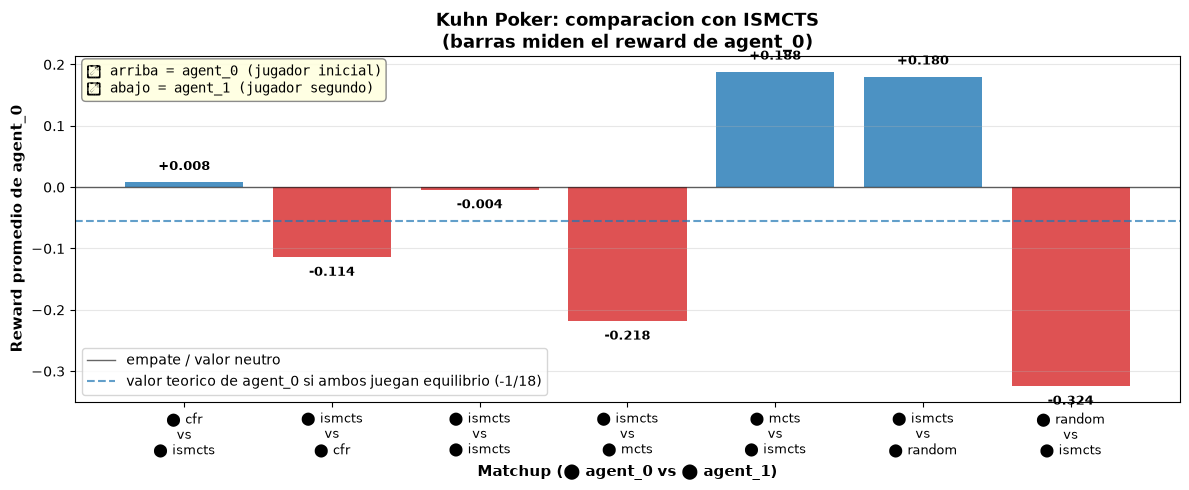


INTERPRETACION
• agent_0 siempre es el PRIMER agente (jugador inicial)
• agent_1 siempre es el SEGUNDO agente
• Valores POSITIVOS (azul): agent_0 gana mas
• Valores NEGATIVOS (rojo): agent_1 gana mas

Mejor resultado para agent_0: mcts (agent_0) vs ismcts (agent_1) → +0.188
Peor resultado para agent_0: random (agent_0) vs ismcts (agent_1) → -0.324

Nota: Barra cercana a 0 o a -1/18 indica juego mas equilibrado.


In [15]:
labels = [
    f"⬤ {r['agent_0_kind']}\nvs\n⬤ {r['agent_1_kind']}"
    for r in ismcts_results
]
values = [r['agent_0_value'] for r in ismcts_results]
kuhn_value = 1 / 18

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['tab:blue' if value >= 0 else 'tab:red' for value in values]
bars = ax.bar(labels, values, color=colors, alpha=0.8)

ax.axhline(0, color='black', linewidth=1, alpha=0.6, label='empate / valor neutro')
ax.axhline(
    -kuhn_value,
    color='tab:blue',
    linestyle='--',
    alpha=0.7,
    label='valor teorico de agent_0 si ambos juegan equilibrio (-1/18)',
)

for bar, value in zip(bars, values):
    offset = 0.015 if value >= 0 else -0.015
    va = 'bottom' if value >= 0 else 'top'
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + offset,
        f'{value:+.3f}',
        ha='center',
        va=va,
        fontsize=9,
        fontweight='bold'
    )

ax.text(
    0.01,
    0.98,
    '⬤ arriba = agent_0 (jugador inicial)\n⬤ abajo = agent_1 (jugador segundo)',
    transform=ax.transAxes,
    va='top',
    fontsize=10,
    bbox={'boxstyle': 'round', 'facecolor': 'lightyellow', 'alpha': 0.9, 'edgecolor': 'gray'},
    fontfamily='monospace'
)
ax.set_title('Kuhn Poker: comparacion con ISMCTS\n(barras miden el reward de agent_0)', fontsize=13, fontweight='bold')
ax.set_ylabel('Reward promedio de agent_0', fontsize=11, fontweight='bold')
ax.set_xlabel('Matchup (⬤ agent_0 vs ⬤ agent_1)', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', rotation=0, labelsize=9)
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

best = max(ismcts_results, key=lambda r: r['agent_0_value'])
worst = min(ismcts_results, key=lambda r: r['agent_0_value'])
print(
    '\n' + '='*80 + '\n'
    'INTERPRETACION\n'
    + '='*80 + '\n'
    f"• agent_0 siempre es el PRIMER agente (jugador inicial)\n"
    f"• agent_1 siempre es el SEGUNDO agente\n"
    f"• Valores POSITIVOS (azul): agent_0 gana mas\n"
    f"• Valores NEGATIVOS (rojo): agent_1 gana mas\n\n"
    f"Mejor resultado para agent_0: {best['agent_0_kind']} (agent_0) vs {best['agent_1_kind']} (agent_1) → {best['agent_0_value']:+.3f}\n"
    f"Peor resultado para agent_0: {worst['agent_0_kind']} (agent_0) vs {worst['agent_1_kind']} (agent_1) → {worst['agent_0_value']:+.3f}\n"
    f"\nNota: Barra cercana a 0 o a -1/18 indica juego mas equilibrado.\n"
    + '='*80
)